In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from tqdm import tqdm  # Provides the progress of model running

In [2]:
glass = pd.read_csv('D:/Machine_Learning/Cases/Glass_Identification/Glass.csv')
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,building_windows_float_processed
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,headlamps
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,headlamps
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,headlamps
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,headlamps


In [3]:
le = LabelEncoder()
glass['Type'] = le.fit_transform(glass['Type'])
X , y = glass.drop(['Type'], axis=1), glass['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26, stratify= y)

In [12]:
le.classes_

array(['building_windows_float_processed',
       'building_windows_non_float_processed', 'containers', 'headlamps',
       'tableware', 'vehicle_windows_float_processed'], dtype=object)

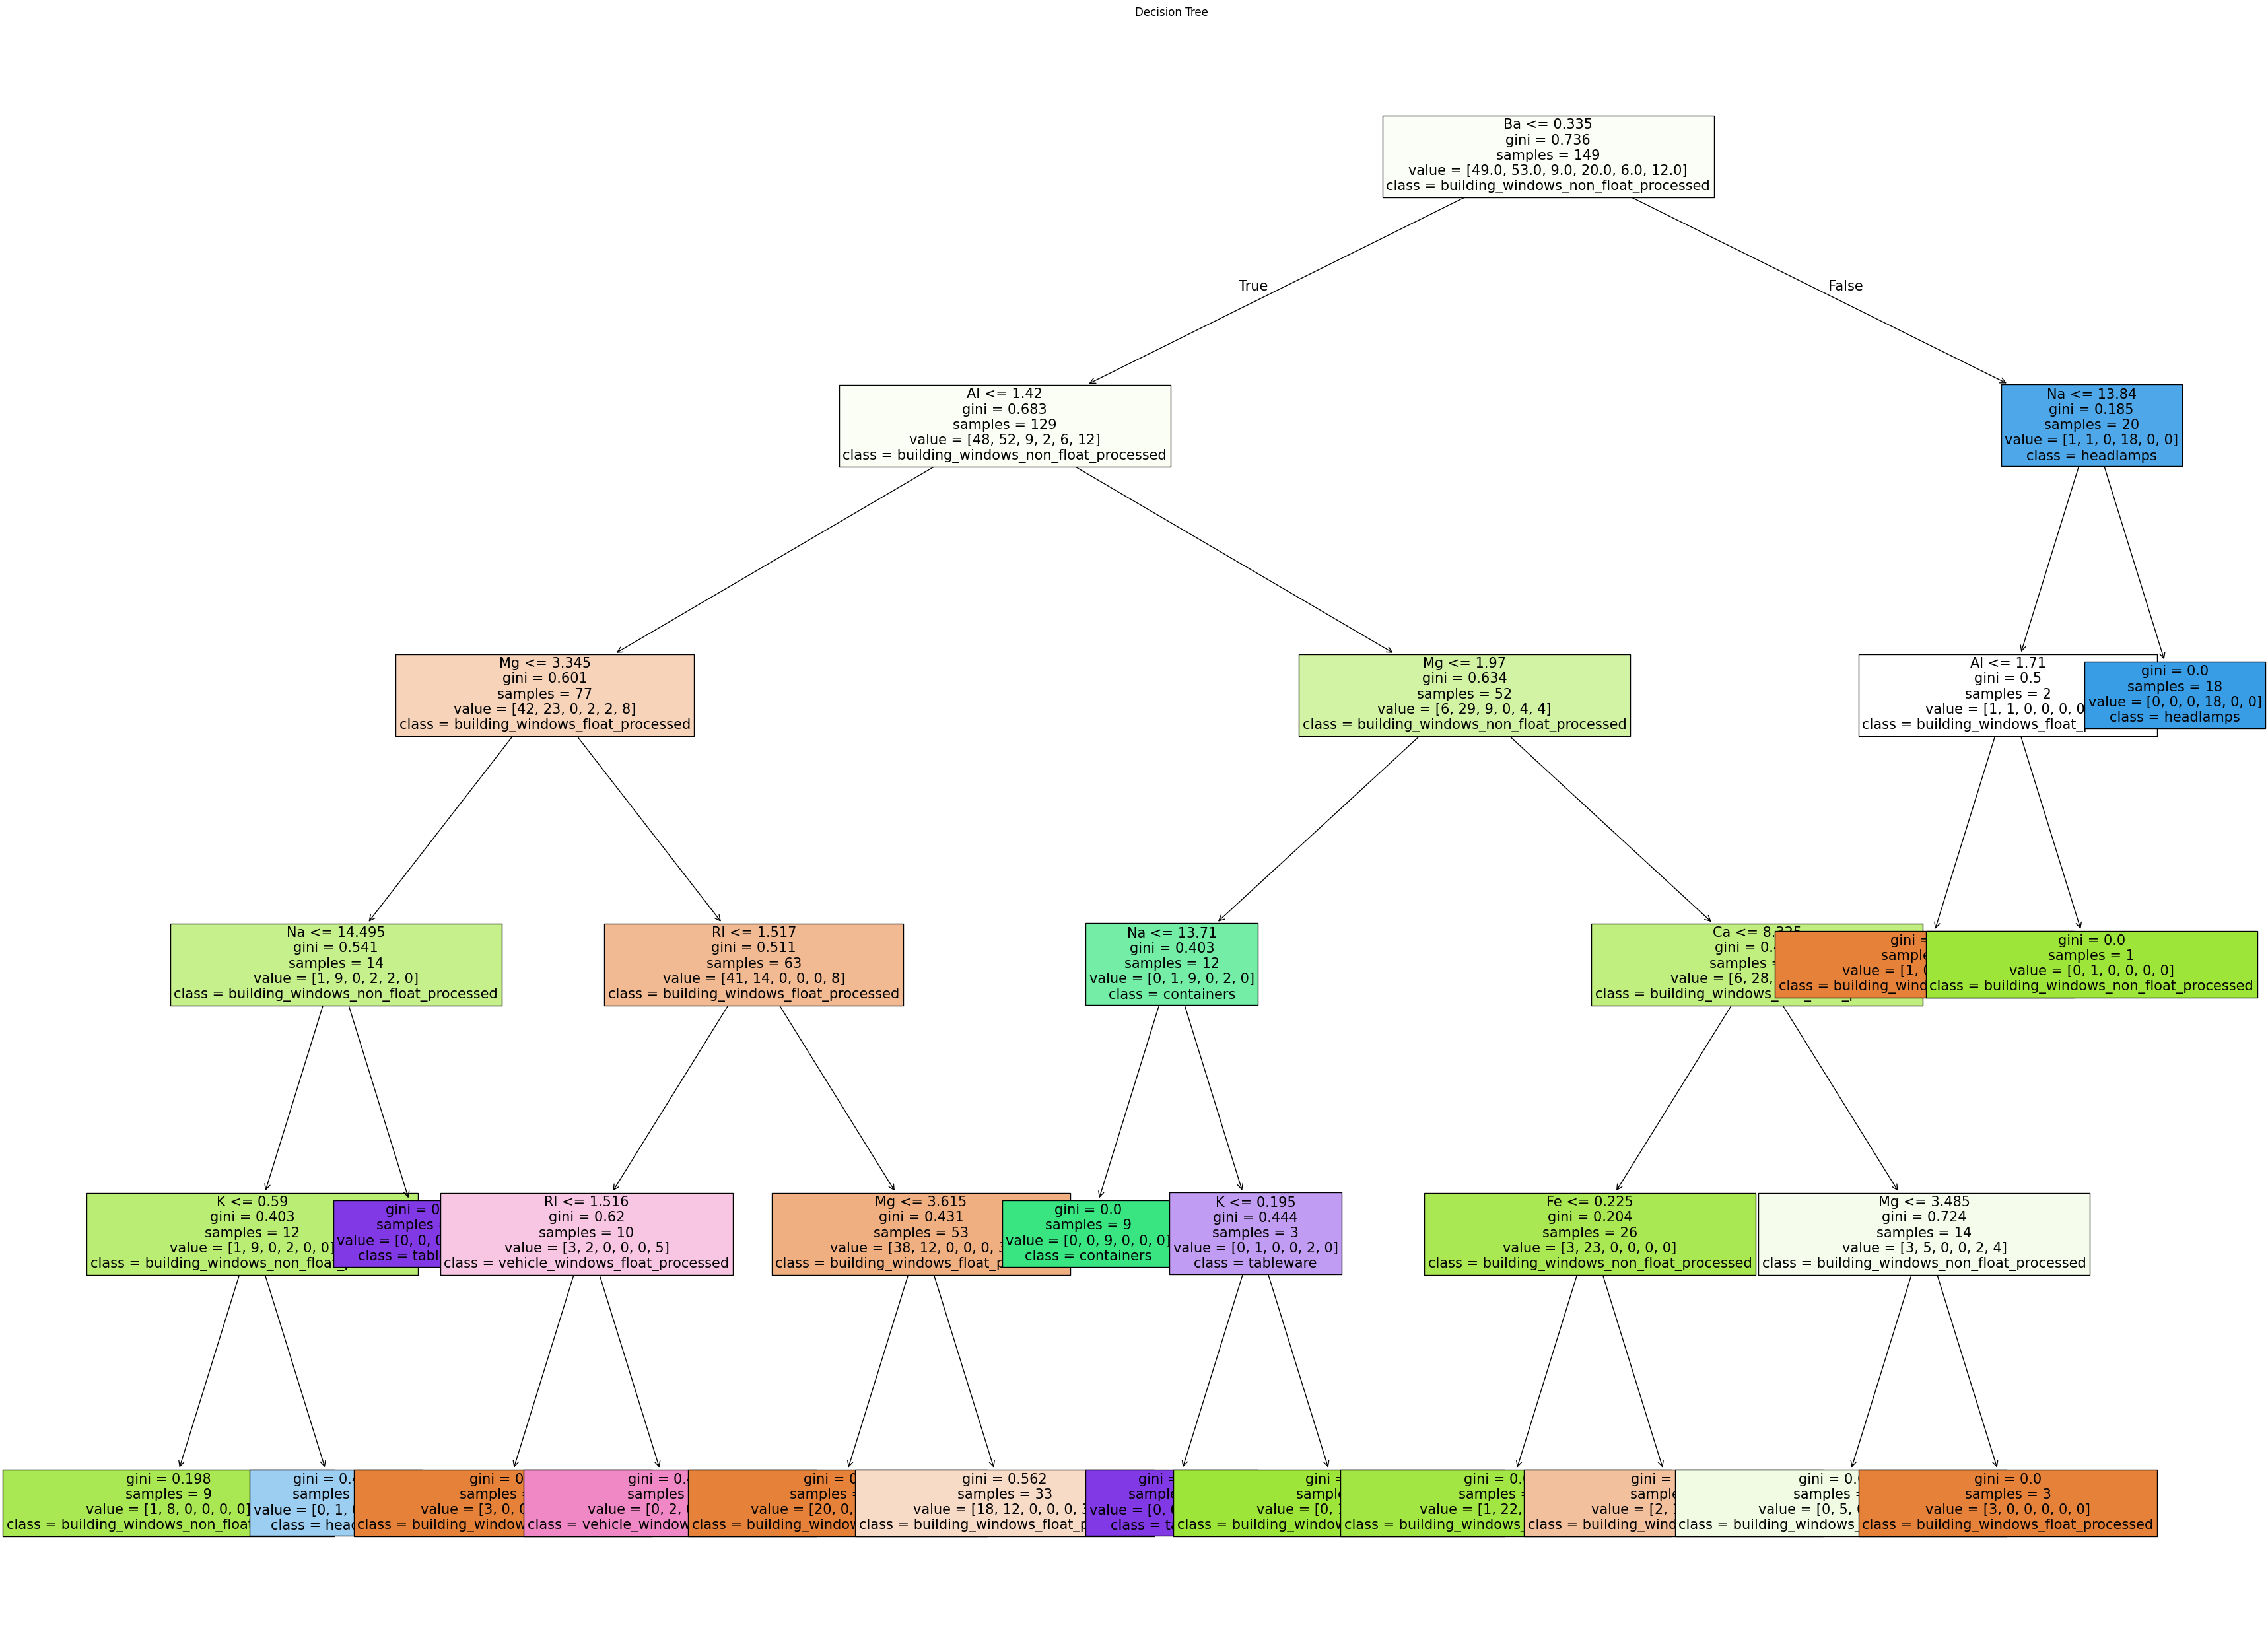

In [11]:
dtc = DecisionTreeClassifier(random_state=26, max_depth=5)
dtc.fit(X_train, y_train)
plt.figure(figsize=(35,25))
plot_tree(dtc, feature_names=list(X.columns), class_names=le.classes_, filled=True, fontsize=15)
plt.title("Decision Tree")
plt.tight_layout()
plt.show()

In [6]:
depths = [1,2,3,5,None]  # take random values instead of np.arange
splits = [2,4,8,10,20,30,50,100]
leaves= [1,4,8,10,20,30,46,50,100]
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeClassifier(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_test)
            y_pred_prob = dtc.predict_proba(X_test)
            
            scores.append([d, s, l, accuracy_score(y_test, y_pred), log_loss(y_test, y_pred_prob)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'Accuracy', 'log_loss' ])
df_scores.sort_values(['log_loss'], ascending=True).head()

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:02<00:00,  2.11it/s]


,Depth,Splits,Leaves,Accuracy,log_loss
330,NaN,20,46,0.523077,1.208317
294,NaN,2,46,0.523077,1.208317
321,NaN,10,46,0.523077,1.208317
276,5.0,50,46,0.523077,1.208317
303,NaN,4,46,0.523077,1.208317


# Best Tree

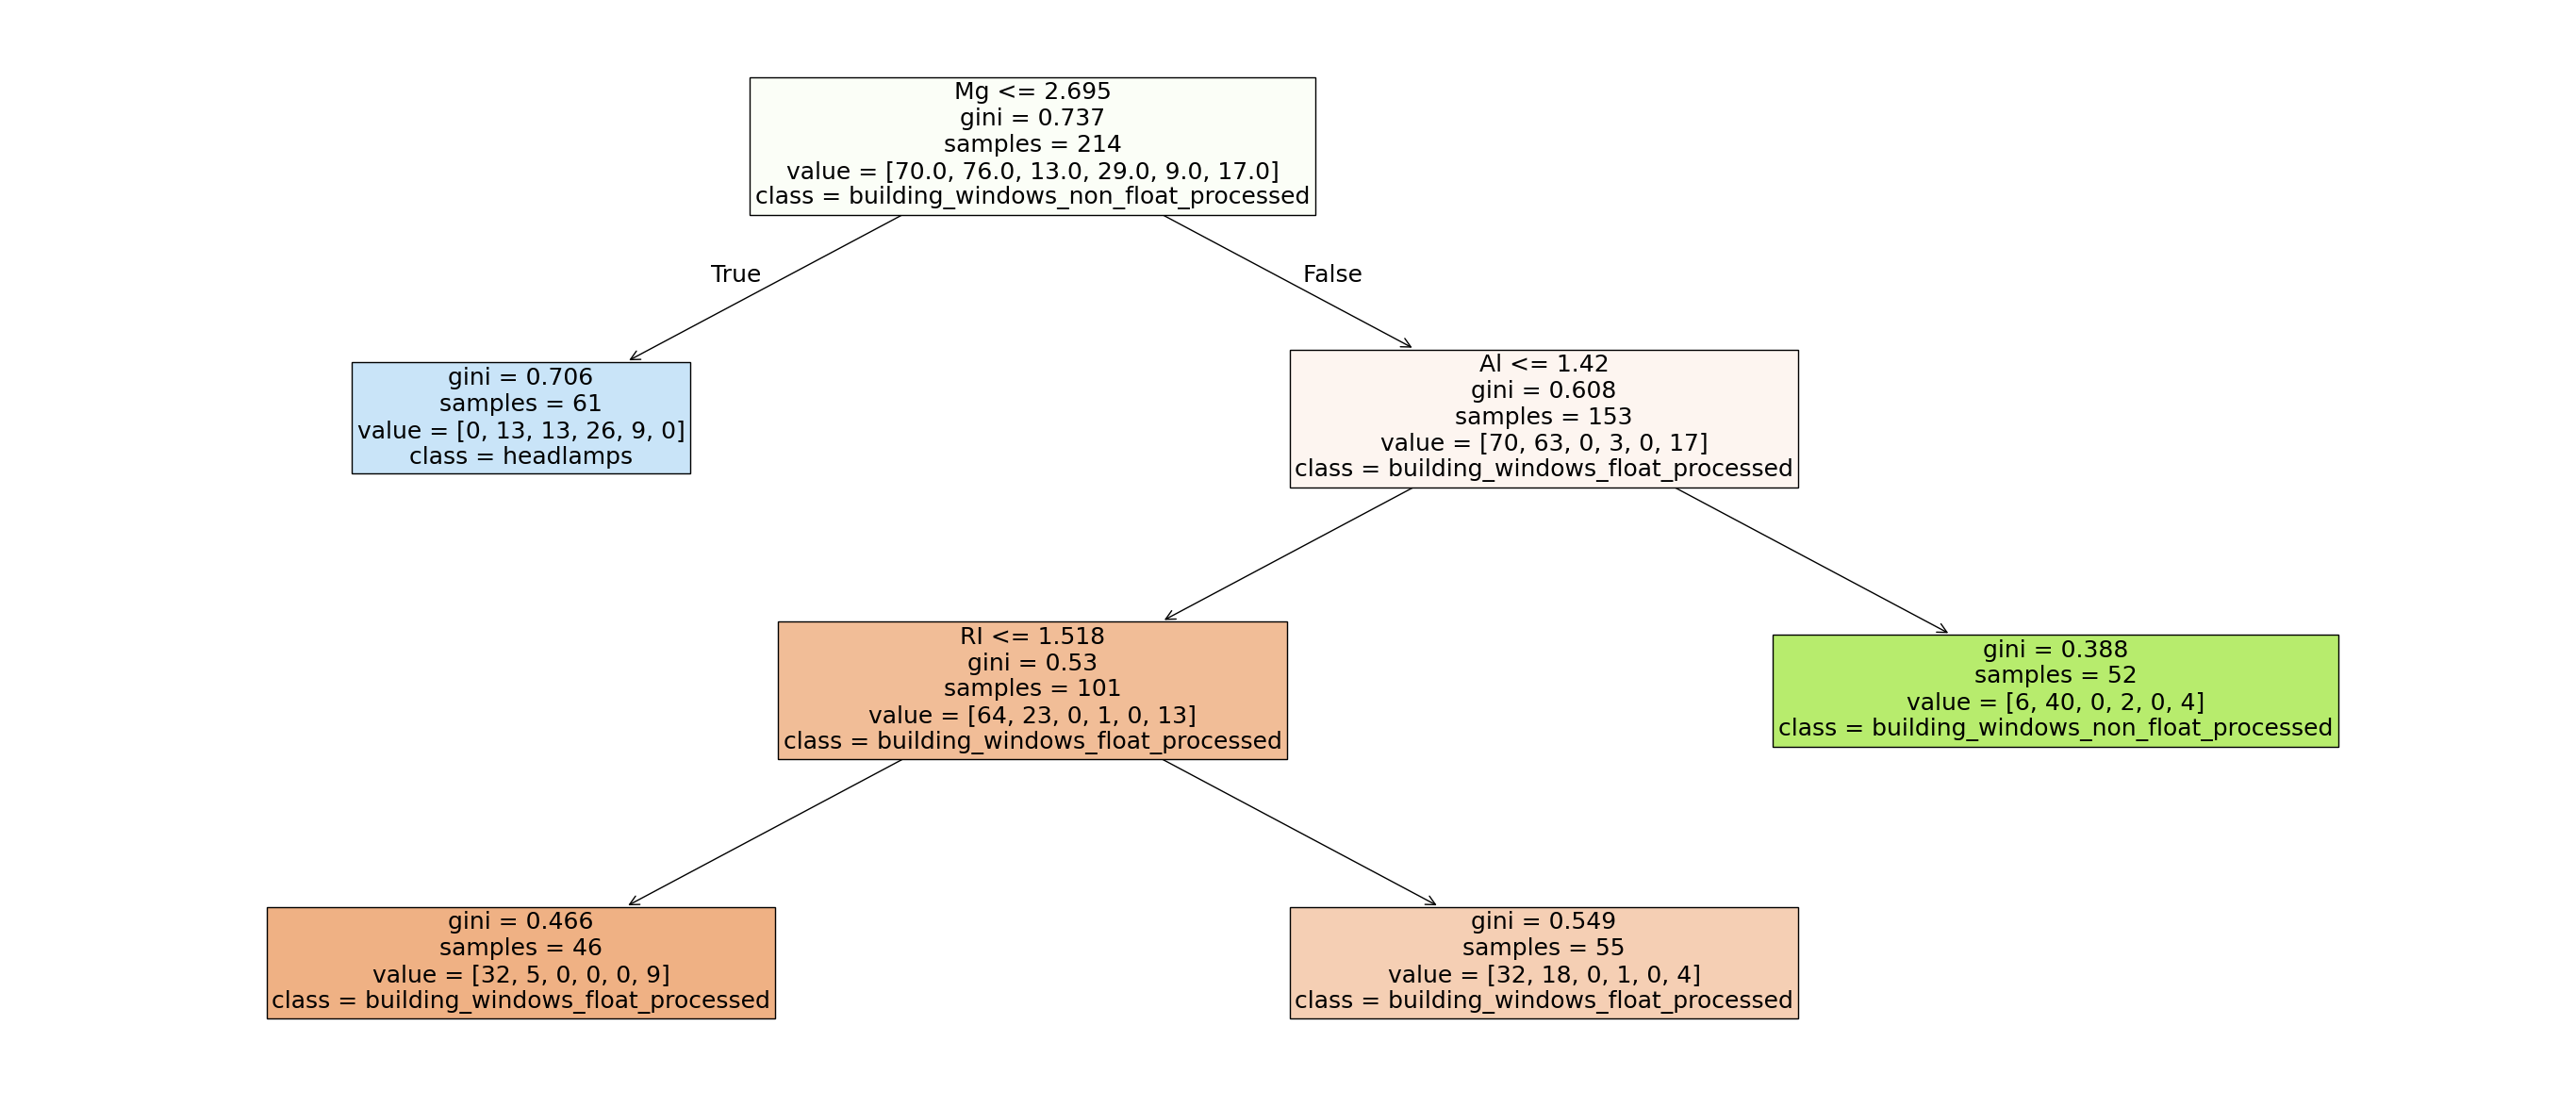

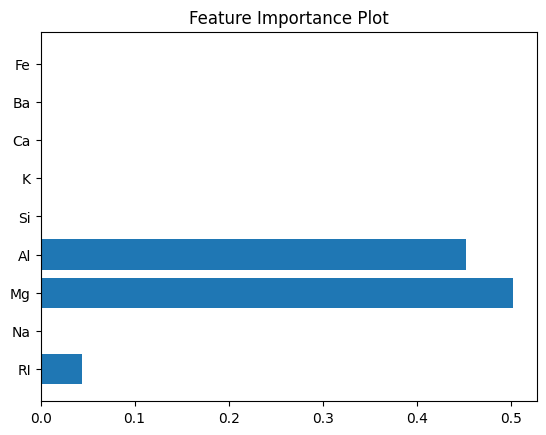

In [9]:
bm =  DecisionTreeClassifier(random_state=26, max_depth=5, min_samples_split=10, min_samples_leaf=46)
bm.fit(X,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X.columns), class_names=le.classes_, filled=True, fontsize=18)
plt.show()

df_imp = pd.DataFrame({'feature':X.columns, 'importance':bm.feature_importances_})
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()